# Gradient Descent on Quadratic Functions

For a **quadratic** $f(x) = \frac{1}{2}x^\top A x - b^\top x$ with symmetric positive definite $A$, gradient descent admits exact analysis.

## Convergence on quadratics

With constant step $\tau$, the error $e^k = x^k - x^*$ satisfies:
$$
e^{k+1} = (I - \tau A)\, e^k.
$$
The spectral radius of $(I - \tau A)$ determines convergence. Writing $A = Q \Lambda Q^\top$ in eigenbasis:
$$
\|e^k\|_A \le \max_i |1 - \tau \lambda_i|^k \|e^0\|_A.
$$
The **optimal step** $\tau^* = 2/(\lambda_{\min} + \lambda_{\max})$ minimises $\max_i |1 - \tau\lambda_i|$, giving contraction factor:
$$
\rho = \frac{\kappa - 1}{\kappa + 1}, \qquad \kappa = \frac{\lambda_{\max}}{\lambda_{\min}}.
$$

## Condition number and convergence speed

For large $\kappa$: $\rho \approx 1 - 2/\kappa$, so the number of iterations to reduce the error by $1/e$ is $\approx \kappa/2$. A **well-conditioned** problem ($\kappa$ small) converges fast; an **ill-conditioned** one ($\kappa$ large) converges very slowly.

## Exact line search

For a quadratic, the **optimal step size** at each iteration is:
$$
\tau^k = \frac{\|g^k\|^2}{\langle g^k, A g^k\rangle}, \quad g^k = \nabla f(x^k) = Ax^k - b.
$$
Exact line search also converges with rate $\rho = (\kappa-1)/(\kappa+1)$ asymptotically, but can be faster in practice.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Effect of condition number

We compare GD on 2D anisotropic quadratics $f(x,y) = \frac{1}{2}(x^2 + \kappa y^2)$ for several $\kappa$.

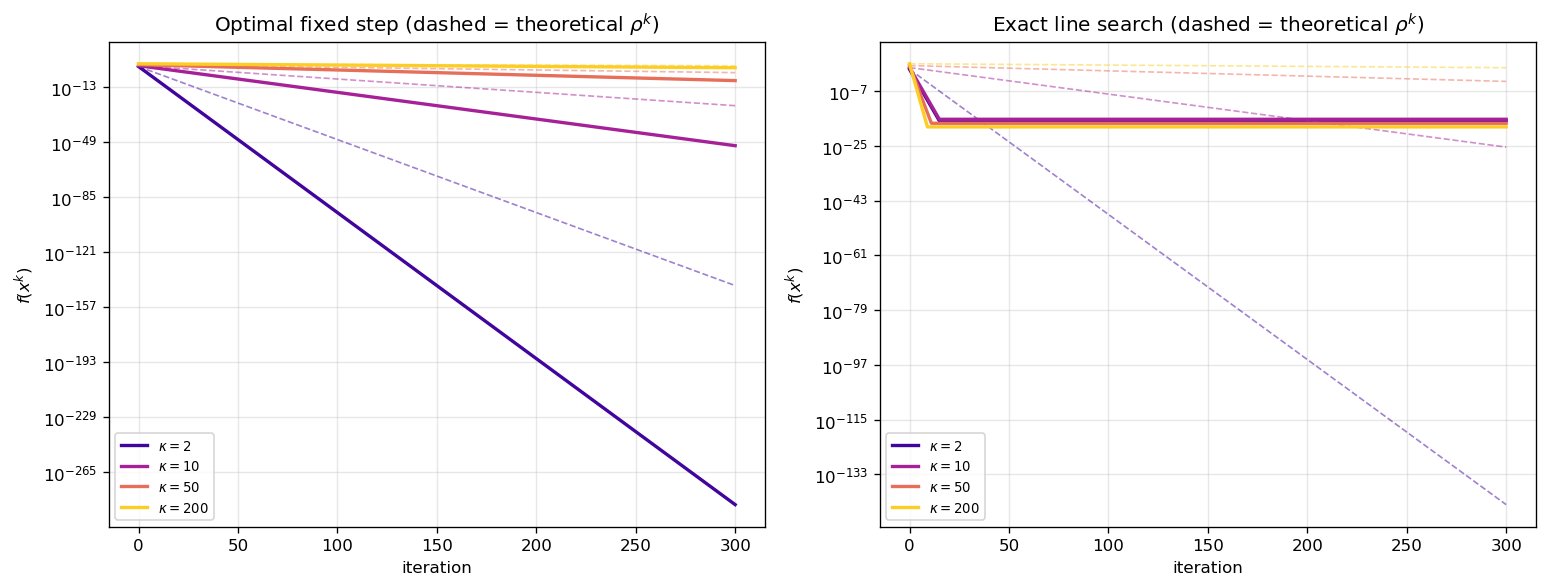

In [2]:
def gd_quad(kappa, n_iter=300):
    """GD on f = 0.5*(x^2 + kappa*y^2) from (1,1), optimal step."""
    mu, L = 1.0, float(kappa)
    tau = 2.0 / (mu + L)
    x = np.array([1.0, 1.0])
    fvals = [0.5*(mu*x[0]**2 + L*x[1]**2)]
    for _ in range(n_iter):
        g = np.array([mu*x[0], L*x[1]])
        x = x - tau * g
        fvals.append(0.5*(mu*x[0]**2 + L*x[1]**2))
    return np.array(fvals)

def gd_quad_ls(kappa, n_iter=300):
    """GD with exact line search."""
    mu, L = 1.0, float(kappa)
    A = np.diag([mu, L])
    x = np.array([1.0, 1.0])
    fvals = [0.5*(mu*x[0]**2 + L*x[1]**2)]
    for _ in range(n_iter):
        g = A @ x
        grad_sq = np.dot(g, g)
        if grad_sq <= np.finfo(float).eps:
            fvals.extend([fvals[-1]] * (n_iter - len(fvals) + 1))
            break
        tau = grad_sq / np.dot(g, A @ g)
        x = x - tau * g
        fvals.append(0.5*(mu*x[0]**2 + L*x[1]**2))
    return np.array(fvals)

kappas = [2, 10, 50, 200]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
k_idx = np.arange(301)
cols = plt.cm.plasma(np.linspace(0.1, 0.9, len(kappas)))

for kappa, col in zip(kappas, cols):
    rho = (kappa - 1)/(kappa + 1)
    f_opt = gd_quad(kappa)
    f_ls  = gd_quad_ls(kappa)
    axes[0].semilogy(f_opt, lw=2, color=col, label=f'$\\kappa={kappa}$')
    axes[0].semilogy(k_idx, f_opt[0]*rho**k_idx, lw=1, ls='--', color=col, alpha=0.5)
    axes[1].semilogy(f_ls, lw=2, color=col, label=f'$\\kappa={kappa}$')
    axes[1].semilogy(k_idx, f_opt[0]*rho**k_idx, lw=1, ls='--', color=col, alpha=0.5)

for ax, title in zip(axes, ['Optimal fixed step', 'Exact line search']):
    ax.set_xlabel('iteration'); ax.set_ylabel('$f(x^k)$')
    ax.set_title(title + ' (dashed = theoretical $\\rho^k$)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Trajectories and level sets

Visualising the zig-zag behaviour: GD alternately overshoots along the steep direction and under-shoots along the flat direction.

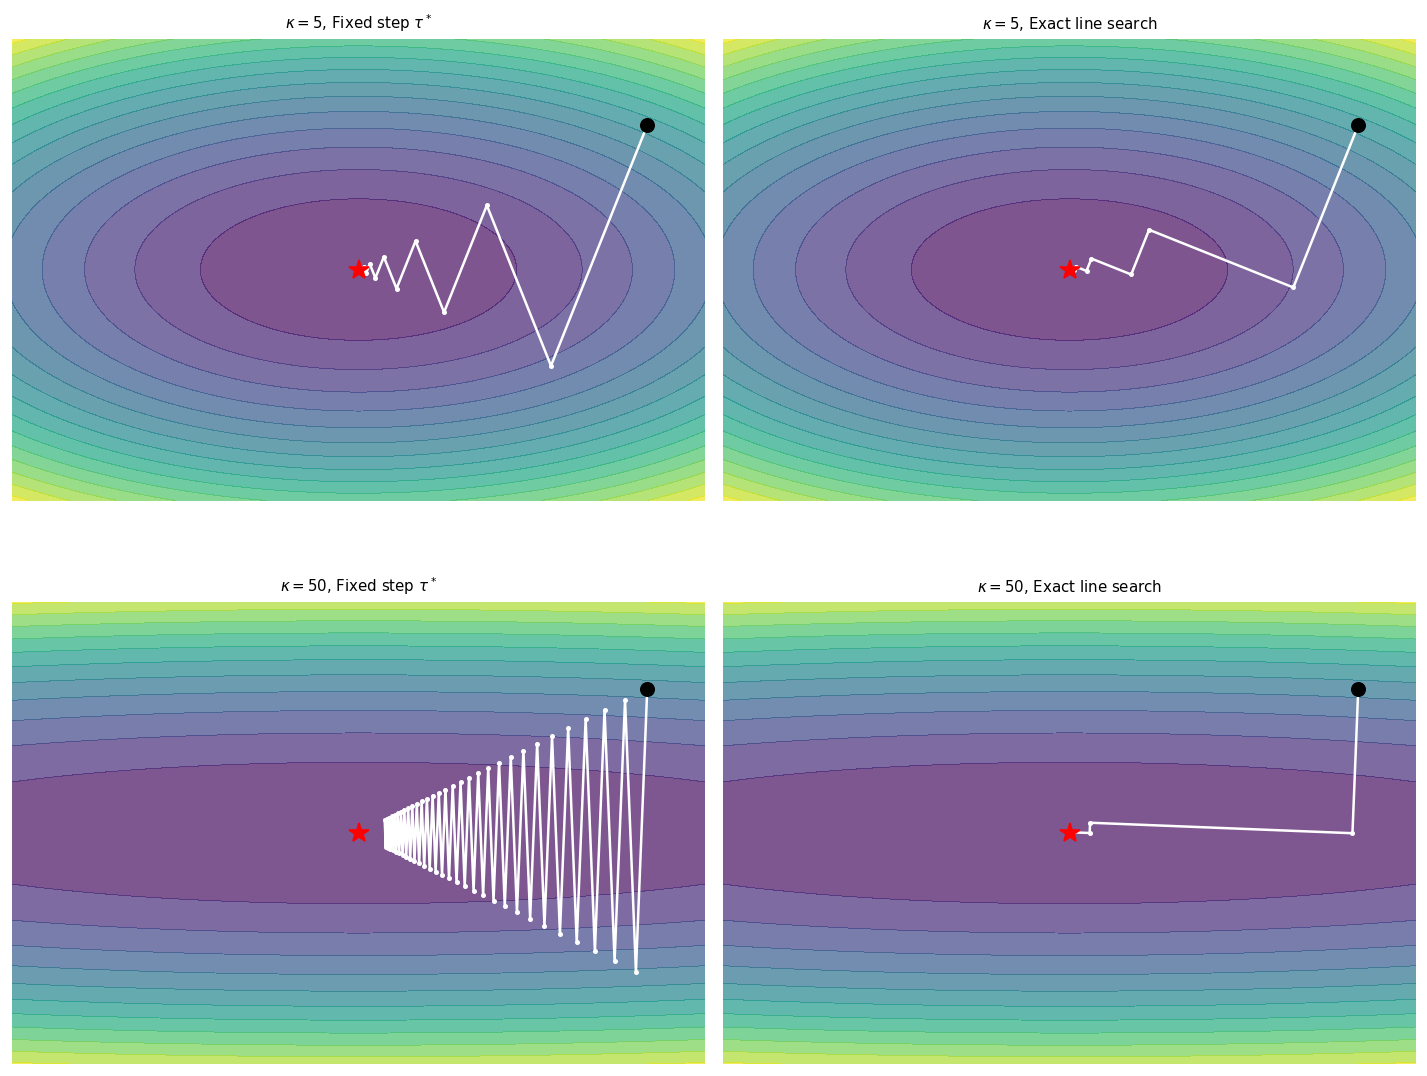

In [3]:
def gd_traj(kappa, n_iter, use_ls=False):
    mu, L = 1.0, float(kappa)
    A = np.diag([mu, L])
    x = np.array([1.0, 0.5]); traj = [x.copy()]
    tau_fix = 2.0 / (mu + L)
    for _ in range(n_iter):
        g = A @ x
        tau = np.dot(g,g)/np.dot(g, A@g) if use_ls else tau_fix
        x = x - tau * g; traj.append(x.copy())
    return np.array(traj)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
kappa_list = [5, 50]

for row, kappa in enumerate(kappa_list):
    mu, L = 1.0, float(kappa)
    xi = np.linspace(-1.2, 1.2, 200); yi = np.linspace(-0.8, 0.8, 200)
    X, Y = np.meshgrid(xi, yi)
    F = 0.5*(mu*X**2 + L*Y**2)
    for col, (use_ls, name) in enumerate([(False,'Fixed step $\\tau^*$'), (True,'Exact line search')]):
        ax = axes[row, col]
        t = gd_traj(kappa, 60, use_ls)
        ax.contourf(xi, yi, F, levels=15, cmap='viridis', alpha=0.7)
        ax.plot(t[:,0], t[:,1], 'w.-', lw=1.5, ms=4)
        ax.plot(t[0,0], t[0,1], 'ko', ms=8); ax.plot(0, 0, 'r*', ms=12)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(f'$\\kappa={kappa}$, {name}', fontsize=9)

plt.tight_layout(); plt.show()

## Interactive: condition number

In [4]:
def show_quad(kappa=20, n_iter=200):
    mu, L = 1.0, float(kappa)
    f_opt = gd_quad(kappa, n_iter)
    f_ls  = gd_quad_ls(kappa, n_iter)
    k = np.arange(n_iter+1)
    rho = (kappa-1)/(kappa+1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].semilogy(f_opt, 'royalblue', lw=2, label='Fixed step')
    axes[0].semilogy(f_ls,  'tomato', lw=2, label='Line search')
    axes[0].semilogy(k, f_opt[0]*rho**k, 'k--', lw=1, alpha=0.5, label=f'$\\rho^k$, $\\rho={rho:.3f}$')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel('iteration'); axes[0].set_ylabel('$f(x^k)$')
    axes[0].set_title(f'Convergence ($\\kappa={kappa}$)')
    xi = np.linspace(-1.2,1.2,150); yi = np.linspace(-0.8,0.8,150)
    X,Y = np.meshgrid(xi,yi)
    axes[1].contourf(xi, yi, 0.5*(mu*X**2+L*Y**2), levels=15, cmap='viridis', alpha=0.7)
    t = gd_traj(kappa, n_iter)
    axes[1].plot(t[:,0], t[:,1], 'w.-', lw=1.5, ms=3)
    axes[1].plot(t[0,0], t[0,1], 'ko', ms=8); axes[1].plot(0,0,'r*',ms=12)
    axes[1].set_aspect('equal'); axes[1].axis('off')
    axes[1].set_title('Trajectory (fixed step)')
    plt.tight_layout(); plt.show()

interact(show_quad,
         kappa=IntSlider(value=20, min=2, max=300, step=5, description='$\\kappa$'),
         n_iter=IntSlider(value=200, min=50, max=500, step=50, description='iters'));

interactive(children=(IntSlider(value=20, description='$\\kappa$', max=300, min=2, step=5), IntSlider(value=20…

## Bibliographical resources

- Akaike, H. (1959). On a successive transformation of probability distribution and its application to the analysis of the optimum gradient method. *Annals of the Institute of Statistical Mathematics*, 11(1), 1–16.
- Kantorovich, L. V. (1948). Functional analysis and applied mathematics. *Uspekhi Matematicheskikh Nauk*, 3(6), 89–185.
- Nocedal, J. and Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer. Chapter 3.
- Boyd, S. and Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. Chapter 9.
- Trefethen, L. N. and Bau, D. (1997). *Numerical Linear Algebra*. SIAM.